# PUC-SP - AI
## Inteligência Artificial
### Big Data e Data Engineering

https://www.pucsp.br/pos-graduacao/especializacao-mba/inteligencia-artificial

## LAB de Big Data
## SQL GCP BigQuery - Data Warehouse

- Ambiente: Google Colab + BigQuery
- Dataset: diversos: `bigquery-public-data`  

Experimentar a escrita e execução de consultas SQL em um ambiente de Big Data voltado para Data Warehouse, utilizando dados estruturados organizados em tabelas no formato relacional (cartesiano), com o objetivo de explorar, analisar e extrair insights a partir de grandes volumes de dados públicos.



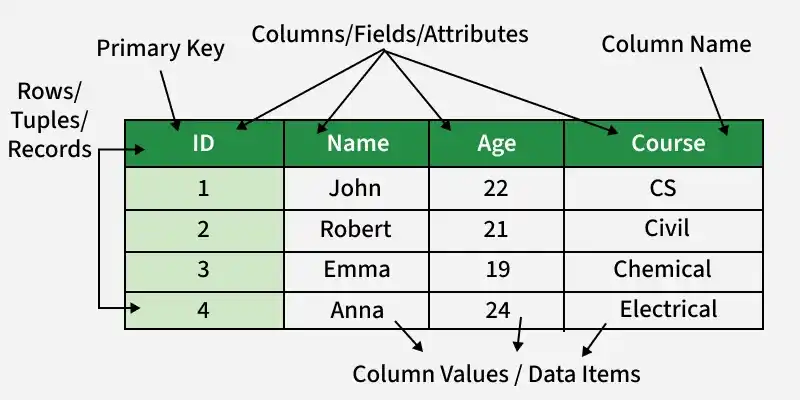

https://www.geeksforgeeks.org/dbms/rdbms-full-form/

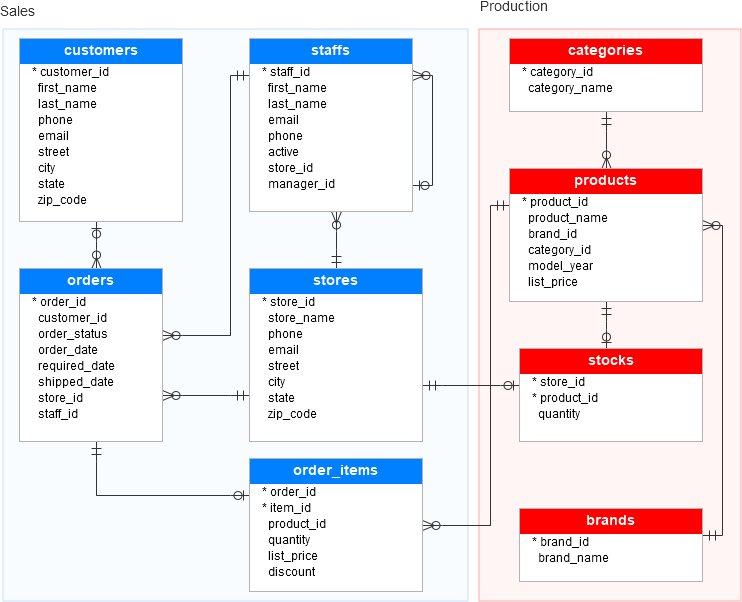

https://www.sqlservertutorial.net/getting-started/sql-server-sample-database/

GCP BigQuery é o data warehouse totalmente gerenciado e serverless do Google Cloud, projetado para análise em escala de petabytes usando SQL padrão. Sua arquitetura separa completamente armazenamento e processamento: os dados ficam no Colossus (sistema de arquivos distribuído do Google) em formato colunar proprietário chamado Capacitor, enquanto as consultas rodam no Dremel, um motor de processamento massivamente paralelo que distribui o trabalho entre milhares de workers via a rede interna de altíssima velocidade do Google, a Jupiter. Por não exigir provisionamento de cluster, o BigQuery escala automaticamente conforme o volume de dados e a complexidade da consulta, cobrando por armazenamento (por petabyte) e processamento (por slot-segundo ou por byte lido) de forma independente — o que o torna especialmente adequado para cargas de trabalho analíticas variáveis, sem a necessidade de administrar infraestrutura.

No contexto de **Big Data**, o **BigQuery** ocupa o papel de camada analítica de um **data warehouse** moderno, otimizada para consultas **SQL** estruturadas e agregações rápidas sobre volumes massivos de dados já organizados em esquemas (schemas) definidos — ele responde perguntas de negócio com alta performance, mas exige que os dados estejam relativamente limpos e modelados antes de chegar lá. Um data lake, por outro lado, é um repositório de armazenamento bruto (raw data, tipicamente sobre algo como Google Cloud Storage, Amazon S3 ou HDFS) que aceita dados estruturados, semiestruturados e não estruturados — logs, imagens, JSON, vídeo, sensores de IoT — sem exigir um schema definido no momento da ingestão (schema-on-read em vez de schema-on-write). A diferença central é essa: o data warehouse (BigQuery) prioriza dados curados, estrutura e velocidade de consulta para decisões de negócio, enquanto o data lake prioriza flexibilidade, custo baixo de armazenamento e a capacidade de guardar qualquer tipo de dado antes mesmo de saber como ele será usado — sendo mais adequado para ciência de dados exploratória, machine learning e retenção de dados brutos em longo prazo. Na prática, muitas arquiteturas de Big Data combinam os dois em um modelo de "data lakehouse", onde o lake serve como camada bruta e econômica, e ferramentas como o BigQuery (que inclusive consegue consultar diretamente dados armazenados no Cloud Storage via tabelas externas) atuam como a camada analítica sobre esses dados já refinados.

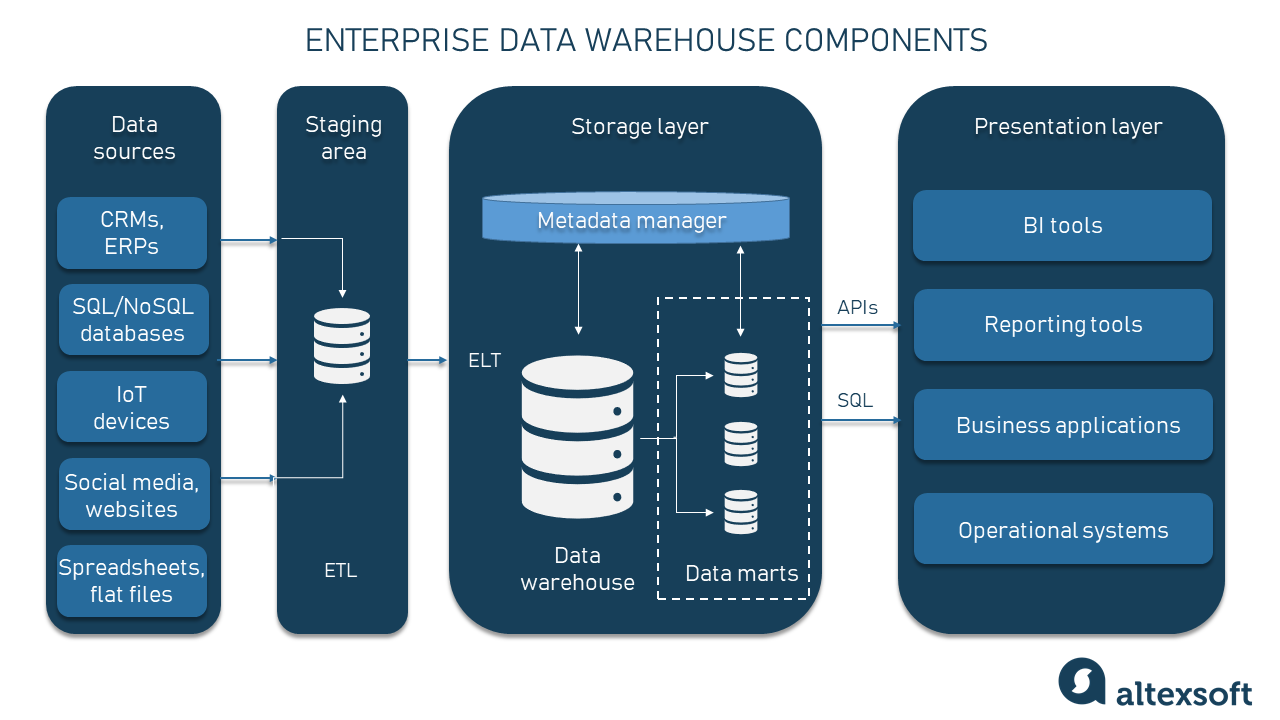

https://www.altexsoft.com/blog/enterprise-data-warehouse-concepts/

## BigQuery Tech

A Tecnologia por Trás do Google BigQuery

A arquitetura do BigQuery se apoia em cinco tecnologias internas do Google, com armazenamento e
processamento (compute) completamente desacoplados um do outro.

## Dremel — o motor de consultas

É o motor de execução MPP (processamento massivamente paralelo) que roda as consultas SQL. O Dremel
quebra uma consulta em uma árvore de sub-tarefas e as distribui entre milhares de workers
simultaneamente, implementando uma "serving tree" (árvore de execução) de múltiplos níveis:

- **Root Node (nó raiz):** coordena as atividades dos leaf nodes e mixers.
- **Mixers:** cuidam da agregação e do processamento dos resultados.
- **Leaf Nodes (nós folha):** leem os dados diretamente do Colossus.

A capacidade de processamento é medida em **slots**. O Dremel distribui slots dinamicamente entre
as consultas conforme a demanda, mantendo justiça entre consultas concorrentes de múltiplos
usuários — um único usuário pode receber milhares de slots para rodar suas consultas.

## Colossus — a camada de armazenamento

É o sistema de arquivos distribuído do Google (sucessor do GFS — Google File System). O BigQuery
armazena todos os dados das tabelas nele, completamente separado da camada de compute. O Colossus
cuida de replicação, durabilidade e geo-distribuição de forma transparente para o usuário.

## Capacitor — o formato de armazenamento

É o formato de armazenamento colunar proprietário do BigQuery, que substituiu o formato anterior
(ColumnIO) em 2016. Cada coluna de uma tabela é armazenada separadamente, o que melhora tanto a
compressão quanto a velocidade das consultas. Cada arquivo Capacitor contém os dados da coluna já
comprimidos, informações de codificação, estatísticas (mínimo, máximo, contagem de nulos) e
dicionários para colunas de texto — é isso que permite que uma consulta que usa 2 colunas de um
total de 200 evite ler as outras 198.

## Jupiter — a rede interna

Como compute e armazenamento rodam em máquinas separadas, dados e resultados precisam trafegar
constantemente pela rede. O Jupiter fornece uma malha de rede bidirecional de escala petabit,
garantindo que ler dados pela rede seja tão rápido quanto ler de um disco local — rápido o
suficiente para que armazenar dados separadamente do compute seja uma vantagem, e não uma
limitação.

## Borg — o gerenciador de cluster

É o sistema de gerenciamento de cluster do Google — o precursor interno do Kubernetes. É o Borg que
permite ao Dremel escalar instantaneamente milhares de workers paralelos para uma consulta grande,
e depois desligá-los assim que ela termina.

## Por que o desacoplamento importa

Como armazenamento e compute escalam de forma independente, você nunca paga por infraestrutura
ociosa — você paga pelos petabytes armazenados no Colossus e pelos slot-segundos de compute
utilizados, ao contrário dos data warehouses tradicionais, onde é preciso comprar um cluster de
tamanho fixo antecipadamente.

## Consequência prática

O BigQuery não tem índices tradicionais em nível de linha — ele depende de **particionamento** e
**clustering** para reduzir a quantidade de dados lida. É por isso que um `SELECT *` custa caro e
por que filtros de coluna e de partição importam tanto para custo e desempenho.

## SQL no Contexto de Big Data

No cenário de Big Data, o SQL deixou de ser apenas a linguagem dos bancos de dados relacionais
tradicionais e se tornou a interface universal de acesso a dados, mesmo em sistemas que nasceram
fora do modelo relacional clássico. Motores de processamento distribuído como Apache Spark
(Spark SQL), Apache Hive e o próprio Google BigQuery expõem uma camada SQL sobre arquiteturas
massivamente paralelas, permitindo que analistas e cientistas de dados consultem petabytes de
dados armazenados em formatos colunares (como Parquet ou Capacitor) sem precisar escrever código
de baixo nível em Java, Scala ou Python. Por trás dessa camada declarativa, o motor traduz a
consulta SQL em um plano de execução distribuído — dividindo o trabalho em tarefas de `map` e
`reduce`, paralelizando entre milhares de nós, e otimizando automaticamente aspectos como poda de
partições (*partition pruning*) e leitura seletiva de colunas. Essa combinação é o que torna o SQL
tão relevante em Big Data: ele preserva a simplicidade declarativa de décadas atrás, mas agora roda
sobre motores como Dremel (BigQuery) ou Catalyst (Spark), capazes de escalar horizontalmente para
lidar com volumes de dados que seriam impossíveis de processar em uma única máquina. Por isso, o
domínio de SQL continua sendo um pré-requisito essencial mesmo em pipelines modernos de Big Data,
funcionando como a linguagem comum entre data lakes, data warehouses e ferramentas de
processamento distribuído.

SQL é uma linguagem de programação declarativa de quarta geração, relativamente simples de aprender, mas que exige tempo e dedicação para se atingir o domínio completo (mastery). Por ser altamente aderente às demandas de negócios, permite traduzir diretamente perguntas do dia a dia, como faturamento, retenção de clientes ou desempenho de vendas, em consultas claras e objetivas, sem exigir conhecimento profundo de programação. Essa característica a torna acessível tanto para desenvolvedores quanto para analistas de negócio e a mantém, mesmo após décadas de existência, como uma das linguagens mais duradouras e indispensáveis no universo de dados.



## LAB: SQL no GCP BigQuery

Vamos fazer algumas consultas direto no console do GCP (WEB), há diversas base de dados disponíveis para uso no BigQuery: **bigquery-public-data**

Vamos fazer algumas consultas SQL e revisar a linguagem...

https://console.cloud.google.com/bigquery

---
## BigQuery SQL 1

Esta query tem como objetivo calcular a expectativa de vida média de mulheres (girls) e homens (boys) por ano e por país, a partir da tabela pública de mortalidade e expectativa de vida do Census Bureau International no BigQuery, agrupando os resultados para permitir a análise comparativa da longevidade entre os sexos ao longo do tempo e entre diferentes nações.



In [ ]:
%%sql

SELECT
  year,
  country_name,
  avg(life_expectancy_female) girls,
  avg(life_expectancy_male) boys
FROM
  `bigquery-public-data.census_bureau_international.mortality_life_expectancy`
GROUP BY
  year,
  country_name;

Dados copy & past do console do BigQuery:

In [ ]:
import pandas as pd

life_df = pd.DataFrame([{
  "year": "1981",
  "country_name": "Aruba",
  "girls": "76.56",
  "boys": "69.09"
}, {
  "year": "1982",
  "country_name": "Aruba",
  "girls": "76.55",
  "boys": "69.14"
}, {
  "year": "1983",
  "country_name": "Aruba",
  "girls": "76.53",
  "boys": "69.19"
}, {
  "year": "1984",
  "country_name": "Aruba",
  "girls": "76.51",
  "boys": "69.24"
}, {
  "year": "1985",
  "country_name": "Aruba",
  "girls": "76.49",
  "boys": "69.29"
}, {
  "year": "1986",
  "country_name": "Aruba",
  "girls": "76.47",
  "boys": "69.34"
}, {
  "year": "1987",
  "country_name": "Aruba",
  "girls": "76.44",
  "boys": "69.38"
}, {
  "year": "1988",
  "country_name": "Aruba",
  "girls": "76.42",
  "boys": "69.43"
}, {
  "year": "1989",
  "country_name": "Aruba",
  "girls": "76.39",
  "boys": "69.47"
}, {
  "year": "1990",
  "country_name": "Aruba",
  "girls": "76.36",
  "boys": "69.51"
}, {
  "year": "1991",
  "country_name": "Aruba",
  "girls": "76.33",
  "boys": "69.55"
}, {
  "year": "1992",
  "country_name": "Aruba",
  "girls": "76.29",
  "boys": "69.59"
}, {
  "year": "1993",
  "country_name": "Aruba",
  "girls": "76.26",
  "boys": "69.63"
}, {
  "year": "1994",
  "country_name": "Aruba",
  "girls": "76.22",
  "boys": "69.66"
}, {
  "year": "1995",
  "country_name": "Aruba",
  "girls": "76.18",
  "boys": "69.7"
}, {
  "year": "1996",
  "country_name": "Aruba",
  "girls": "76.14",
  "boys": "69.73"
}, {
  "year": "1997",
  "country_name": "Aruba",
  "girls": "76.1",
  "boys": "69.77"
}, {
  "year": "1998",
  "country_name": "Aruba",
  "girls": "76.06",
  "boys": "69.8"
}, {
  "year": "1999",
  "country_name": "Aruba",
  "girls": "76.01",
  "boys": "69.83"
}, {
  "year": "2000",
  "country_name": "Aruba",
  "girls": "75.96",
  "boys": "69.86"
}, {
  "year": "2001",
  "country_name": "Aruba",
  "girls": "76.26",
  "boys": "70.17"
}, {
  "year": "2002",
  "country_name": "Aruba",
  "girls": "76.56",
  "boys": "70.47"
}, {
  "year": "2003",
  "country_name": "Aruba",
  "girls": "76.85",
  "boys": "70.77"
}, {
  "year": "2004",
  "country_name": "Aruba",
  "girls": "77.15",
  "boys": "71.06"
}, {
  "year": "2005",
  "country_name": "Aruba",
  "girls": "77.44",
  "boys": "71.35"
}, {
  "year": "2006",
  "country_name": "Aruba",
  "girls": "77.67",
  "boys": "71.58"
}, {
  "year": "2007",
  "country_name": "Aruba",
  "girls": "77.91",
  "boys": "71.8"
}, {
  "year": "2008",
  "country_name": "Aruba",
  "girls": "78.14",
  "boys": "72.03"
}, {
  "year": "2009",
  "country_name": "Aruba",
  "girls": "78.38",
  "boys": "72.25"
}, {
  "year": "2010",
  "country_name": "Aruba",
  "girls": "78.61",
  "boys": "72.47"
}, {
  "year": "2011",
  "country_name": "Aruba",
  "girls": "78.82",
  "boys": "72.68"
}, {
  "year": "2012",
  "country_name": "Aruba",
  "girls": "79.04",
  "boys": "72.89"
}, {
  "year": "2013",
  "country_name": "Aruba",
  "girls": "79.25",
  "boys": "73.09"
}, {
  "year": "2014",
  "country_name": "Aruba",
  "girls": "79.47",
  "boys": "73.3"
}, {
  "year": "2015",
  "country_name": "Aruba",
  "girls": "79.68",
  "boys": "73.5"
}, {
  "year": "2016",
  "country_name": "Aruba",
  "girls": "79.87",
  "boys": "73.69"
}, {
  "year": "2017",
  "country_name": "Aruba",
  "girls": "80.07",
  "boys": "73.88"
}, {
  "year": "2018",
  "country_name": "Aruba",
  "girls": "80.26",
  "boys": "74.07"
}, {
  "year": "2019",
  "country_name": "Aruba",
  "girls": "80.46",
  "boys": "74.26"
}, {
  "year": "2020",
  "country_name": "Aruba",
  "girls": "80.65",
  "boys": "74.44"
}, {
  "year": "2021",
  "country_name": "Aruba",
  "girls": "80.83",
  "boys": "74.62"
}, {
  "year": "2022",
  "country_name": "Aruba",
  "girls": "81.0",
  "boys": "74.79"
}, {
  "year": "2023",
  "country_name": "Aruba",
  "girls": "81.18",
  "boys": "74.96"
}, {
  "year": "2024",
  "country_name": "Aruba",
  "girls": "81.35",
  "boys": "75.13"
}, {
  "year": "2025",
  "country_name": "Aruba",
  "girls": "81.53",
  "boys": "75.3"
}, {
  "year": "2026",
  "country_name": "Aruba",
  "girls": "81.69",
  "boys": "75.46"
}, {
  "year": "2027",
  "country_name": "Aruba",
  "girls": "81.84",
  "boys": "75.62"
}, {
  "year": "2028",
  "country_name": "Aruba",
  "girls": "82.0",
  "boys": "75.77"
}, {
  "year": "2029",
  "country_name": "Aruba",
  "girls": "82.15",
  "boys": "75.93"
}, {
  "year": "2030",
  "country_name": "Aruba",
  "girls": "82.31",
  "boys": "76.08"
}, {
  "year": "2031",
  "country_name": "Aruba",
  "girls": "82.45",
  "boys": "76.22"
}, {
  "year": "2032",
  "country_name": "Aruba",
  "girls": "82.59",
  "boys": "76.36"
}, {
  "year": "2033",
  "country_name": "Aruba",
  "girls": "82.74",
  "boys": "76.5"
}, {
  "year": "2034",
  "country_name": "Aruba",
  "girls": "82.88",
  "boys": "76.64"
}, {
  "year": "2035",
  "country_name": "Aruba",
  "girls": "83.02",
  "boys": "76.78"
}, {
  "year": "2036",
  "country_name": "Aruba",
  "girls": "83.15",
  "boys": "76.91"
}, {
  "year": "2037",
  "country_name": "Aruba",
  "girls": "83.27",
  "boys": "77.04"
}, {
  "year": "2038",
  "country_name": "Aruba",
  "girls": "83.4",
  "boys": "77.17"
}, {
  "year": "1989",
  "country_name": "Belarus",
  "girls": "76.03",
  "boys": "66.57"
}, {
  "year": "1990",
  "country_name": "Belarus",
  "girls": "75.85",
  "boys": "66.29"
}, {
  "year": "1991",
  "country_name": "Belarus",
  "girls": "75.55",
  "boys": "65.59"
}, {
  "year": "1992",
  "country_name": "Belarus",
  "girls": "75.47",
  "boys": "65.01"
}, {
  "year": "1993",
  "country_name": "Belarus",
  "girls": "74.69",
  "boys": "63.84"
}, {
  "year": "1994",
  "country_name": "Belarus",
  "girls": "74.57",
  "boys": "63.57"
}, {
  "year": "1995",
  "country_name": "Belarus",
  "girls": "74.4",
  "boys": "63.0"
}, {
  "year": "1996",
  "country_name": "Belarus",
  "girls": "74.51",
  "boys": "63.21"
}, {
  "year": "1997",
  "country_name": "Belarus",
  "girls": "74.41",
  "boys": "62.95"
}, {
  "year": "1998",
  "country_name": "Belarus",
  "girls": "74.52",
  "boys": "62.72"
}, {
  "year": "1999",
  "country_name": "Belarus",
  "girls": "74.18",
  "boys": "62.31"
}, {
  "year": "2000",
  "country_name": "Belarus",
  "girls": "74.98",
  "boys": "63.47"
}, {
  "year": "2001",
  "country_name": "Belarus",
  "girls": "74.82",
  "boys": "62.9"
}, {
  "year": "2002",
  "country_name": "Belarus",
  "girls": "74.43",
  "boys": "62.37"
}, {
  "year": "2003",
  "country_name": "Belarus",
  "girls": "75.01",
  "boys": "62.8"
}, {
  "year": "2004",
  "country_name": "Belarus",
  "girls": "75.33",
  "boys": "63.32"
}, {
  "year": "2005",
  "country_name": "Belarus",
  "girls": "75.45",
  "boys": "63.11"
}, {
  "year": "2006",
  "country_name": "Belarus",
  "girls": "75.84",
  "boys": "63.72"
}, {
  "year": "2007",
  "country_name": "Belarus",
  "girls": "76.67",
  "boys": "64.88"
}, {
  "year": "2008",
  "country_name": "Belarus",
  "girls": "76.96",
  "boys": "64.97"
}, {
  "year": "2009",
  "country_name": "Belarus",
  "girls": "76.92",
  "boys": "65.09"
}, {
  "year": "2010",
  "country_name": "Belarus",
  "girls": "76.96",
  "boys": "64.96"
}, {
  "year": "2011",
  "country_name": "Belarus",
  "girls": "77.25",
  "boys": "65.35"
}, {
  "year": "2012",
  "country_name": "Belarus",
  "girls": "77.53",
  "boys": "65.75"
}, {
  "year": "2013",
  "country_name": "Belarus",
  "girls": "77.82",
  "boys": "66.14"
}, {
  "year": "2014",
  "country_name": "Belarus",
  "girls": "78.1",
  "boys": "66.53"
}, {
  "year": "2015",
  "country_name": "Belarus",
  "girls": "78.38",
  "boys": "66.91"
}, {
  "year": "2016",
  "country_name": "Belarus",
  "girls": "78.6",
  "boys": "67.2"
}, {
  "year": "2017",
  "country_name": "Belarus",
  "girls": "78.82",
  "boys": "67.49"
}, {
  "year": "2018",
  "country_name": "Belarus",
  "girls": "79.04",
  "boys": "67.78"
}, {
  "year": "2019",
  "country_name": "Belarus",
  "girls": "79.25",
  "boys": "68.06"
}, {
  "year": "2020",
  "country_name": "Belarus",
  "girls": "79.47",
  "boys": "68.34"
}, {
  "year": "2021",
  "country_name": "Belarus",
  "girls": "79.67",
  "boys": "68.61"
}, {
  "year": "2022",
  "country_name": "Belarus",
  "girls": "79.87",
  "boys": "68.88"
}])

# Convert 'girls' and 'boys' columns to numeric
life_df['girls'] = pd.to_numeric(life_df['girls'])
life_df['boys'] = pd.to_numeric(life_df['boys'])


Estatística descritiva dos dados do data frame Pandas:

In [ ]:
life_df.describe()

,girls,boys
count,92.000000,92.000000
mean,78.038478,69.792609
std,2.594044,4.391644
min,74.180000,62.310000
25%,76.170000,66.252500
50%,77.200000,69.610000
75%,79.870000,73.547500
max,83.400000,77.170000


Verificando os anos disponíveis nesta amostra de dados:

In [ ]:
life_df["year"]

,year
0,1981
1,1982
2,1983
3,1984
4,1985
...,...
87,2018
88,2019
89,2020
90,2021


Vamos usar só os dados de 2022:

In [ ]:
life_df.query("year == '2022'")

,year,country_name,girls,boys
41,2022,Aruba,81.00,74.79
91,2022,Belarus,79.87,68.88


Visualização com o Seaborn `jointplot`, que calcula a regressão linear (AI ML):

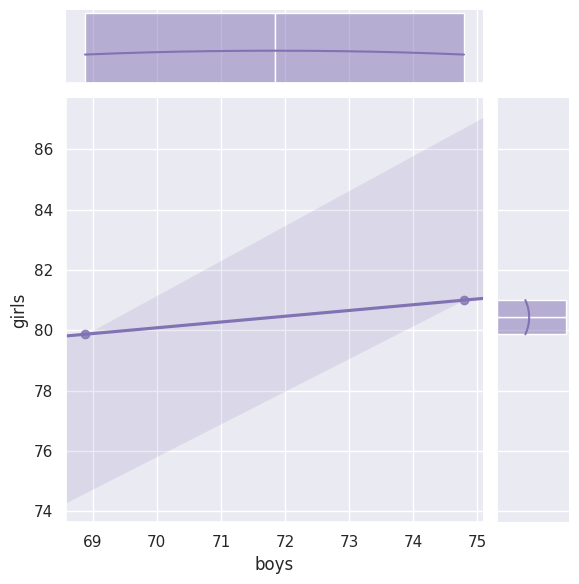

In [ ]:
import seaborn as sns
sns.set_theme(style="darkgrid")

g = sns.jointplot(x="boys",
                  y="girls",
                  data=(life_df.query("year == '2022'")),
                  kind="reg",
                  truncate=False,
                  color="m")

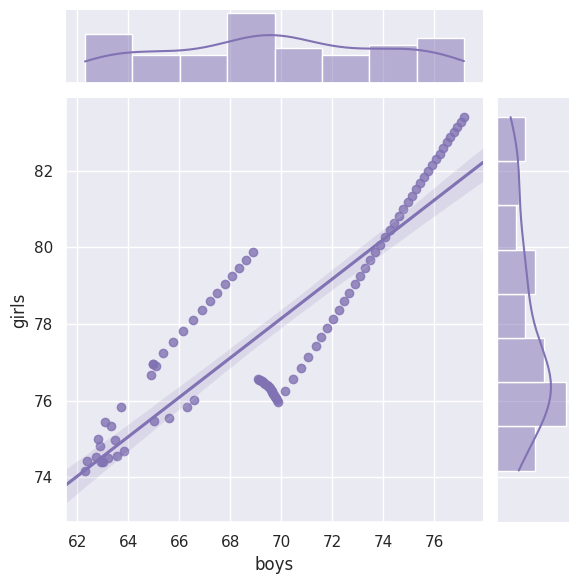

In [ ]:
import seaborn as sns
sns.set_theme(style="darkgrid")

g = sns.jointplot(x="boys",
                  y="girls",
                  data=life_df,
                  kind="reg",
                  truncate=False,
                  color="m")

---
## BigQuery SQL 2

Esta query tem como objetivo visualizar as primeiras 100 linhas completas da tabela pública de solicitações de serviço 311 de Austin no BigQuery, permitindo uma exploração inicial dos dados, incluindo colunas como datas de criação e fechamento, status, tipo de solicitação e localização, para entender a estrutura e o conteúdo do dataset.



In [ ]:
%%sql

select *
  from `bigquery-public-data.austin_311.311_service_requests`
 limit 100

UsageError: Cell magic `%%sql` not found.


---
## BigQuery SQL 3

Esta query tem como objetivo identificar e quantificar os canais de origem (source) das solicitações de serviço 311 de Austin, contando quantas reclamações chegaram por cada fonte, agrupando os resultados por canal, ordenando-os do mais frequente para o menos frequente e limitando a exibição aos 100 primeiros registros, permitindo assim descobrir quais são os meios mais utilizados pelos cidadãos para reportar problemas à prefeitura.



In [ ]:
%%sql

select source,
       count(1) qtd
  from `bigquery-public-data.austin_311.311_service_requests`
 group by source
 order by qtd desc
 limit 100

---
## BigQuery SQL 4

Esta query calcula o tempo de resolução das solicitações de serviço 311 de Austin em número de dias (diferença entre a data de fechamento e a data de criação), conta quantas solicitações foram concluídas em cada intervalo de dias, desconsidera registros com datas nulas, agrupa os resultados pelo tempo de resolução, ordena do intervalo mais frequente para o menos frequente e limita a exibição aos 100 primeiros, permitindo identificar os prazos de atendimento mais comuns.


In [ ]:
%%sql

select TIMESTAMP_DIFF(close_date, created_date, DAY) days_interval,
       count(1)  qtd
  from `bigquery-public-data.austin_311.311_service_requests`
 where created_date is not null
   and close_date is not null
 group by days_interval
 order by qtd desc
 limit 100

UsageError: Cell magic `%%sql` not found.


---
## BigQuery SQL 5

Esta query combina as tabelas de nomes/áreas de países e de expectativa de vida do Census Bureau International, relacionando-as pelo código do país, filtra apenas o ano mais recente disponível nos dados de mortalidade, seleciona o nome do país, sua área territorial e a expectativa de vida correspondente, ordena os resultados pela área do maior para o menor e limita a exibição aos 100 primeiros registros, permitindo analisar a expectativa de vida nos países de maior extensão territorial no período mais atual.



In [ ]:
%%sql

select c.country_name, c.country_area, l.life_expectancy
from `bigquery-public-data.census_bureau_international.country_names_area` c,
     `bigquery-public-data.census_bureau_international.mortality_life_expectancy` l
where c.country_code = l.country_code
  and l.year = (select max(year)
                  from `bigquery-public-data.census_bureau_international.mortality_life_expectancy`)
order by c.country_area desc
limit 100


---
## BigQuery SQL 6

Esta query combina as tabelas de nomes e áreas de países com os dados de população por faixa etária do Census Bureau International, relacionando-as pelo código do país e filtrando apenas o ano mais recente disponível, calcula a população média e a idade média por país, agrupa os resultados por nome e área territorial, ordena os países da maior para a menor área e limita a exibição aos 100 primeiros registros, permitindo analisar o tamanho e a estrutura etária da população nos países de maior extensão territorial no período mais atual.



In [ ]:
%%sql

select distinct c.country_name,
                c.country_area,
                avg(pop.population) avg_pop,
                avg(pop.age) avg_age
  from `bigquery-public-data.census_bureau_international.country_names_area` c,
       `bigquery-public-data.census_bureau_international.midyear_population_agespecific` pop
 where c.country_code = pop.country_code
   and pop.year = (select max(year)
                     from `bigquery-public-data.census_bureau_international.midyear_population_agespecific`)
 group by c.country_name, c.country_area
 order by c.country_area desc
 limit 100

UsageError: Cell magic `%%sql` not found.


Amostra de dados copiados do BigQuery console:

In [ ]:
pop_df = pd.DataFrame([{
  "country_name": "Russia",
  "country_area": "16377742.0",
  "avg_pop": "643109.33663366351",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "China",
  "country_area": "9326410.0",
  "avg_pop": "6443698.25742574",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "United States",
  "country_area": "9148655.0",
  "avg_pop": "1971922.51980198",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Canada",
  "country_area": "9093507.0",
  "avg_pop": "203641.8217821783",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Brazil",
  "country_area": "8358140.0",
  "avg_pop": "1150020.6782178222",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Australia",
  "country_area": "7682300.0",
  "avg_pop": "143627.42574257424",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "India",
  "country_area": "2973193.0",
  "avg_pop": "8200760.5544554489",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Argentina",
  "country_area": "2736690.0",
  "avg_pop": "267897.25742574246",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Kazakhstan",
  "country_area": "2699700.0",
  "avg_pop": "110084.93069306928",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Algeria",
  "country_area": "2381741.0",
  "avg_pop": "274478.8861386138",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Congo (Kinshasa)",
  "country_area": "2267048.0",
  "avg_pop": "716858.58415841579",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Greenland",
  "country_area": "2166086.0",
  "avg_pop": "244.33663366336631",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Saudi Arabia",
  "country_area": "2149690.0",
  "avg_pop": "232293.62376237617",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Mexico",
  "country_area": "1943945.0",
  "avg_pop": "745383.67821782175",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Sudan",
  "country_area": "1861484.0",
  "avg_pop": "442215.59900990123",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Indonesia",
  "country_area": "1811569.0",
  "avg_pop": "1486055.2772277228",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Libya",
  "country_area": "1759540.0",
  "avg_pop": "44409.227722772281",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Mongolia",
  "country_area": "1553556.0",
  "avg_pop": "18164.67326732674",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Iran",
  "country_area": "1531595.0",
  "avg_pop": "488127.7425742576",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Peru",
  "country_area": "1279996.0",
  "avg_pop": "182889.56930693067",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Niger",
  "country_area": "1266700.0",
  "avg_pop": "218920.0693069307",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Chad",
  "country_area": "1259200.0",
  "avg_pop": "185488.89603960386",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Angola",
  "country_area": "1246700.0",
  "avg_pop": "406826.87128712871",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Mali",
  "country_area": "1220190.0",
  "avg_pop": "206218.34158415842",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "South Africa",
  "country_area": "1214470.0",
  "avg_pop": "339251.73267326714",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Bolivia",
  "country_area": "1083301.0",
  "avg_pop": "79225.930693069313",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Colombia",
  "country_area": "1038700.0",
  "avg_pop": "278354.60396039579",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Mauritania",
  "country_area": "1030700.0",
  "avg_pop": "32357.782178217836",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Ethiopia",
  "country_area": "1000000.0",
  "avg_pop": "1129040.9702970295",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Egypt",
  "country_area": "995450.0",
  "avg_pop": "836326.603960396",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Nigeria",
  "country_area": "910768.0",
  "avg_pop": "2064337.0297029715",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Tanzania",
  "country_area": "885800.0",
  "avg_pop": "587061.44554455427",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Venezuela",
  "country_area": "882050.0",
  "avg_pop": "196817.43564356439",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Namibia",
  "country_area": "823290.0",
  "avg_pop": "20577.396039603955",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Mozambique",
  "country_area": "786380.0",
  "avg_pop": "292071.56930693041",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Pakistan",
  "country_area": "770875.0",
  "avg_pop": "1439840.5445544557",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Turkey",
  "country_area": "769632.0",
  "avg_pop": "442030.32673267339",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Chile",
  "country_area": "743812.0",
  "avg_pop": "97467.69306930693",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Zambia",
  "country_area": "743398.0",
  "avg_pop": "193032.76732673263",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Burma",
  "country_area": "653508.0",
  "avg_pop": "319322.59900990111",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Afghanistan",
  "country_area": "652230.0",
  "avg_pop": "315818.90099009912",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "South Sudan",
  "country_area": "644329.0",
  "avg_pop": "116953.3316831683",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "France",
  "country_area": "640427.0",
  "avg_pop": "343982.57920792076",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Somalia",
  "country_area": "627337.0",
  "avg_pop": "112010.4950495049",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Central African Republic",
  "country_area": "622984.0",
  "avg_pop": "51182.49009900989",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Madagascar",
  "country_area": "581540.0",
  "avg_pop": "226769.97029702985",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Ukraine",
  "country_area": "579330.0",
  "avg_pop": "183901.14356435649",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Kenya",
  "country_area": "569140.0",
  "avg_pop": "350274.55445544544",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Botswana",
  "country_area": "566730.0",
  "avg_pop": "15846.821782178222",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Yemen",
  "country_area": "527968.0",
  "avg_pop": "228121.90594059409",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Thailand",
  "country_area": "510890.0",
  "avg_pop": "327049.49009900988",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Spain",
  "country_area": "498980.0",
  "avg_pop": "259854.65346534658",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Cameroon",
  "country_area": "472710.0",
  "avg_pop": "256991.62871287129",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Turkmenistan",
  "country_area": "469930.0",
  "avg_pop": "32708.331683168326",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Papua New Guinea",
  "country_area": "452860.0",
  "avg_pop": "50049.638613861367",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Morocco",
  "country_area": "446300.0",
  "avg_pop": "208051.72277227731",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Iraq",
  "country_area": "437367.0",
  "avg_pop": "378808.99999999988",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Uzbekistan",
  "country_area": "425400.0",
  "avg_pop": "173843.43564356433",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Sweden",
  "country_area": "410335.0",
  "avg_pop": "59461.663366336616",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Paraguay",
  "country_area": "397302.0",
  "avg_pop": "43762.896039603955",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Zimbabwe",
  "country_area": "386847.0",
  "avg_pop": "126498.66336633667",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Japan",
  "country_area": "364485.0",
  "avg_pop": "530740.27722772292",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Germany",
  "country_area": "348672.0",
  "avg_pop": "354167.8514851486",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Congo (Brazzaville)",
  "country_area": "341500.0",
  "avg_pop": "50504.806930693063",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Malaysia",
  "country_area": "328657.0",
  "avg_pop": "212517.55445544547",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Cote d\u0027Ivoire",
  "country_area": "318003.0",
  "avg_pop": "232788.55940594041",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Vietnam",
  "country_area": "310070.0",
  "avg_pop": "550364.27227722772",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Oman",
  "country_area": "309500.0",
  "avg_pop": "26742.361386138622",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Norway",
  "country_area": "304282.0",
  "avg_pop": "31504.9900990099",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Poland",
  "country_area": "304255.0",
  "avg_pop": "162070.83168316828",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Finland",
  "country_area": "303815.0",
  "avg_pop": "27107.688118811893",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Philippines",
  "country_area": "298170.0",
  "avg_pop": "769209.16831683123",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Italy",
  "country_area": "294140.0",
  "avg_pop": "304038.87128712889",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Ecuador",
  "country_area": "276841.0",
  "avg_pop": "104468.06930693066",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Burkina Faso",
  "country_area": "273800.0",
  "avg_pop": "183214.72277227702",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Western Sahara",
  "country_area": "266000.0",
  "avg_pop": "5808.6633663366356",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "New Zealand",
  "country_area": "264537.0",
  "avg_pop": "25737.584158415837",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Gabon",
  "country_area": "257667.0",
  "avg_pop": "20241.079207920782",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Guinea",
  "country_area": "245717.0",
  "avg_pop": "136296.80693069295",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "United Kingdom",
  "country_area": "241930.0",
  "avg_pop": "352246.51980198035",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Laos",
  "country_area": "230800.0",
  "avg_pop": "49846.509900990095",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Romania",
  "country_area": "229891.0",
  "avg_pop": "89407.693069306959",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Ghana",
  "country_area": "227533.0",
  "avg_pop": "259482.8019801979",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Belarus",
  "country_area": "202900.0",
  "avg_pop": "41285.46534653462",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Uganda",
  "country_area": "197100.0",
  "avg_pop": "462753.60891089111",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Guyana",
  "country_area": "196849.0",
  "avg_pop": "4346.6732673267343",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Senegal",
  "country_area": "192530.0",
  "avg_pop": "134872.06930693076",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Kyrgyzstan",
  "country_area": "191801.0",
  "avg_pop": "34967.084158415841",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Syria",
  "country_area": "183630.0",
  "avg_pop": "154582.87128712868",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Cambodia",
  "country_area": "176515.0",
  "avg_pop": "110588.56930693073",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Uruguay",
  "country_area": "175015.0",
  "avg_pop": "17303.158415841575",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Suriname",
  "country_area": "156000.0",
  "avg_pop": "3554.1386138613866",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Tunisia",
  "country_area": "155360.0",
  "avg_pop": "62768.410891089035",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Nepal",
  "country_area": "143351.0",
  "avg_pop": "164681.98019801982",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Tajikistan",
  "country_area": "141510.0",
  "avg_pop": "60061.2128712871",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Greece",
  "country_area": "130647.0",
  "avg_pop": "49682.846534653472",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Bangladesh",
  "country_area": "130170.0",
  "avg_pop": "955904.76732673275",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Korea, North",
  "country_area": "120408.0",
  "avg_pop": "133511.86138613851",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Nicaragua",
  "country_area": "119990.0",
  "avg_pop": "35810.000000000015",
  "avg_age": "50.000000000000014"
}, {
  "country_name": "Honduras",
  "country_area": "111890.0",
  "avg_pop": "64103.163366336623",
  "avg_age": "50.000000000000014"
}])

# Convert columns to numeric
pop_df['country_area'] = pd.to_numeric(pop_df['country_area'])
#pop_df['population'] = pd.to_numeric(pop_df['population'])
pop_df['avg_pop'] = pd.to_numeric(pop_df['avg_pop'])
pop_df['avg_age'] = pd.to_numeric(pop_df['avg_age'])

Estatística descritiva do data frame Pandas:

In [ ]:
pop_df.describe()

,country_area,avg_pop,avg_age
count,1.000000e+02,1.000000e+02,1.000000e+02
mean,1.284144e+06,4.396168e+05,5.000000e+01
std,2.413995e+06,1.067109e+06,7.141223e-15
min,1.118900e+05,2.443366e+02,5.000000e+01
25%,2.718500e+05,5.739187e+04,5.000000e+01
50%,5.194290e+05,1.892608e+05,5.000000e+01
75%,1.116093e+06,3.507675e+05,5.000000e+01
max,1.637774e+07,8.200761e+06,5.000000e+01


Gráficos do Seaborn, `relplot` scatter plot:

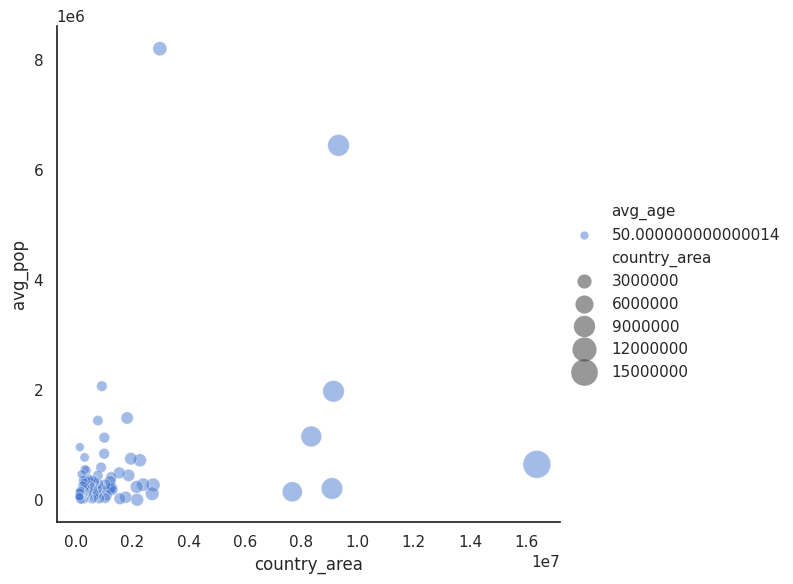

In [ ]:
import seaborn as sns
sns.set_theme(style="white")

sns.relplot(x="country_area",
            y="avg_pop",
            hue="avg_age",
            size="country_area",
            sizes=(40, 400),
            alpha=.5,
            palette="muted",
            height=6,
            data=pop_df)

Visualização com o `boxenplot` do Seaborn:

<Axes: xlabel='country_area', ylabel='avg_pop'>

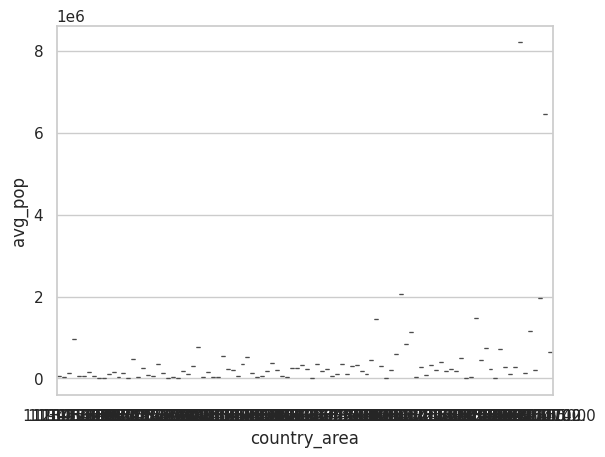

In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")

sns.boxenplot(
    pop_df,
    x="country_area",
    y="avg_pop",
    color="b",
    width_method="exponential"
)

Visualização com os `residplot` do Seaborn, que faz regressão linear (AI ML):

<Axes: xlabel='country_area', ylabel='avg_pop'>

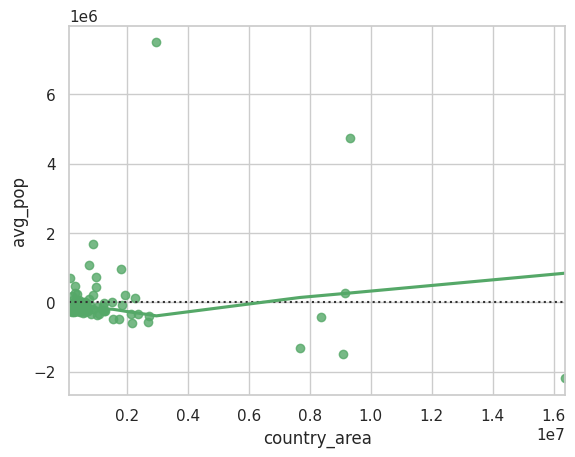

In [ ]:
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")

sns.residplot(data=pop_df,
              x="country_area",
              y="avg_pop",
              lowess=True,
              color="g")

---
## BigQuery SQL 6

Esta query busca e retorna até 100 registros completos da tabela de locais de filmagem em São Francisco, filtrando apenas os filmes cujo título contenha a palavra “House” e que possuam informação de localização preenchida (não nula), permitindo identificar rapidamente produções relacionadas a “House” e os locais onde foram filmadas na cidade.

Podemos obter informações valiosas de dados categóricos e textos.

In [ ]:
%%sql

SELECT title,
       release_year,
       locations,
       IFNULL(fun_facts,"None") fun_facts,
       production_company,
       distributor,
       director,
       IFNULL(writer,"Unknow") writer,
       actor_1,
       actor_2,
       actor_3
FROM `bigquery-public-data.san_francisco_film_locations.film_locations`
WHERE title like '%House%'
  AND locations is not null
LIMIT 100

Amostra de dados de filmes copiados do console do BigQuery, no formato JSON (dict):

In [ ]:
film_df = pd.DataFrame([{
  "title": "The House on Telegraph Hill",
  "release_year": "1951.0",
  "locations": "Coit Tower",
  "fun_facts": "The Tower was funded by a gift bequeathed by Lillie Hitchcock Coit, a socialite who reportedly liked to chase fires. Though the tower resembles a firehose nozzle, it was not designed this way.",
  "production_company": "Twentieth Century Fox Film Corp.",
  "distributor": "Twentieth Century Fox Film Corp.",
  "director": "Robert Wise",
  "writer": "Elick Moll",
  "actor_1": "Richard Basehart",
  "actor_2": "Valentina Cortese",
  "actor_3": "William Lundigan"
}, {
  "title": "The House on Telegraph Hill",
  "release_year": "1951.0",
  "locations": "Market Street",
  "fun_facts": "None",
  "production_company": "Twentieth Century Fox Film Corp.",
  "distributor": "Twentieth Century Fox Film Corp.",
  "director": "Robert Wise",
  "writer": "Elick Moll",
  "actor_1": "Richard Basehart",
  "actor_2": "Valentina Cortese",
  "actor_3": "William Lundigan"
}, {
  "title": "The House on Telegraph Hill",
  "release_year": "1951.0",
  "locations": "1227 Montgomery Street",
  "fun_facts": "None",
  "production_company": "Twentieth Century Fox Film Corp.",
  "distributor": "Twentieth Century Fox Film Corp.",
  "director": "Robert Wise",
  "writer": "Elick Moll",
  "actor_1": "Richard Basehart",
  "actor_2": "Valentina Cortese",
  "actor_3": "William Lundigan"
}, {
  "title": "The House on Telegraph Hill",
  "release_year": "1951.0",
  "locations": "Telegraph Hill",
  "fun_facts": "Largely untouched by the 1906 earthquake, Telegraph Hill has the most pre-1870 buildings in the city.",
  "production_company": "Twentieth Century Fox Film Corp.",
  "distributor": "Twentieth Century Fox Film Corp.",
  "director": "Robert Wise",
  "writer": "Elick Moll",
  "actor_1": "Richard Basehart",
  "actor_2": "Valentina Cortese",
  "actor_3": "William Lundigan"
}, {
  "title": "Chef Dynasty: House of Fang",
  "release_year": "2022.0",
  "locations": "Ritz Carlton, 690 Market Street",
  "fun_facts": "None",
  "production_company": "Quidnet Media, LLC",
  "distributor": "Food Network",
  "director": "nan",
  "writer": "Unknow",
  "actor_1": "Lillian Phan",
  "actor_2": "Long Vo",
  "actor_3": "Christy-Anne Lopez"
}, {
  "title": "Chef Dynasty: House of Fang",
  "release_year": "2022.0",
  "locations": "660 Howard, Fang Chinese Restaurant",
  "fun_facts": "None",
  "production_company": "Quidnet Media, LLC",
  "distributor": "Food Network",
  "director": "nan",
  "writer": "Unknow",
  "actor_1": "Lillian Phan",
  "actor_2": "Long Vo",
  "actor_3": "Christy-Anne Lopez"
}, {
  "title": "Chef Dynasty: House of Fang",
  "release_year": "2022.0",
  "locations": "Chinatown - Grant Avenue between California and Jackson St",
  "fun_facts": "None",
  "production_company": "Quidnet Media, LLC",
  "distributor": "Food Network",
  "director": "nan",
  "writer": "Unknow",
  "actor_1": "Lillian Phan",
  "actor_2": "Long Vo",
  "actor_3": "Christy-Anne Lopez"
}, {
  "title": "Chef Dynasty: House of Fang",
  "release_year": "2022.0",
  "locations": "Asian Art Museum (200 Larkin Street, Civic Center)",
  "fun_facts": "None",
  "production_company": "Quidnet Media, LLC",
  "distributor": "Food Network",
  "director": "nan",
  "writer": "Unknow",
  "actor_1": "Lillian Phan",
  "actor_2": "Long Vo",
  "actor_3": "Christy-Anne Lopez"
}, {
  "title": "Chef Dynasty: House of Fang",
  "release_year": "2022.0",
  "locations": "House of Nanking, 919 Kearny",
  "fun_facts": "None",
  "production_company": "Quidnet Media, LLC",
  "distributor": "Food Network",
  "director": "nan",
  "writer": "Unknow",
  "actor_1": "Lillian Phan",
  "actor_2": "Long Vo",
  "actor_3": "Christy-Anne Lopez"
}])

Endereços de locadoras:

In [ ]:
film_df["locations"]

,locations
0,Coit Tower
1,Market Street
2,1227 Montgomery Street
3,Telegraph Hill
4,"Ritz Carlton, 690 Market Street"
5,"660 Howard, Fang Chinese Restaurant"
6,Chinatown - Grant Avenue between California an...
7,"Asian Art Museum (200 Larkin Street, Civic Cen..."
8,"House of Nanking, 919 Kearny"


Podemos enriquecer a base de dados (enhance) combinando informações de fontes adicionais.

Conheça o OSM Nominatim, para busca de endereços.

https://nominatim.openstreetmap.org/ui/search.html?q=PUC-SP+cONSOLACAO

Esta é a URL da WEB API do OSM que fornece detalhes de endereços, como a geo localização latitude e longitude.

Precisamos no final completar com o endereço de interesse.

In [ ]:
OSM_URL = "https://nominatim.openstreetmap.org/search?format=jsonv2&q="

Importando a LIB `requests` e montando o `headers` para se parecer um browser...

Vamos **hackear** o sistema...

In [ ]:
import requests

headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'}


Assim vamos compor uma URL para buscar o endereço da locadora na WEB API do OSM:

In [ ]:
OSM_URL + film_df["locations"][0].replace(" ", "+")

'https://nominatim.openstreetmap.org/search?format=jsonv2&q=Coit+Tower'

No final da URL para o WEB API (WEB Service) do OSM, concatenamos o endereço, e substituimos espaço em branco por **+**, e enviamos o header para paracer que somos um browser e não um programa buscando dados:

In [ ]:
address = requests.get(OSM_URL + film_df["locations"][0].replace(" ", "+"), headers=headers).json()


In [ ]:
address

[{'place_id': 323257632,
  'licence': 'Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright',
  'osm_type': 'way',
  'osm_id': 28824850,
  'lat': '37.8023791',
  'lon': '-122.4058344',
  'category': 'tourism',
  'type': 'viewpoint',
  'place_rank': 30,
  'importance': 0.4076496563503252,
  'addresstype': 'tourism',
  'name': 'Coit Tower',
  'display_name': 'Coit Tower, Telegraph Hill Boulevard, Telegraph Hill, North Beach, San Francisco, California, 94113, United States',
  'boundingbox': ['37.8022726', '37.8024820', '-122.4059616', '-122.4057063']}]

A WEB API (WEB Service) do OSM fornece os valores de lat e lon como texto (string), convertemos aqui para número (np.array), pois cada coluna do Pandas é uma Série que é um np.array:

In [ ]:
address_df = pd.DataFrame(address)

address_df['lat'] = pd.to_numeric(address_df['lat'])
address_df['lon'] = pd.to_numeric(address_df['lon'])

address_df

,place_id,licence,osm_type,osm_id,lat,lon,category,type,place_rank,importance,addresstype,name,display_name,boundingbox
0,323257632,"Data © OpenStreetMap contributors, ODbL 1.0. h...",way,28824850,37.802379,-122.405834,tourism,viewpoint,30,0.40765,tourism,Coit Tower,"Coit Tower, Telegraph Hill Boulevard, Telegrap...","[37.8022726, 37.8024820, -122.4059616, -122.40..."


Precisamos converter para float do Python:

In [ ]:
float(address_df["lat"][0])

37.8023791

Podemos agora visualizar o endereço com a LIB `folium`, convertendo lat e lon appropriadamente:

In [ ]:
import folium

latitude = float(address_df["lat"][0])
longitude = float(address_df["lon"][0])

locadora = folium.Map(location=[latitude, longitude], zoom_start=14)

folium.Marker(
    location=[latitude, longitude], # O centro do mapa
    popup="Film",
    tooltip="Pick-up it!"
).add_to(locadora) # O marcador

locadora

Agora ainda no contexto de trabalhar com strings, vamos visualizar a coluna "fun_facts":

In [ ]:
film_df.fun_facts

,fun_facts
0,The Tower was funded by a gift bequeathed by L...
1,None
2,None
3,"Largely untouched by the 1906 earthquake, Tele..."
4,None
5,None
6,None
7,None
8,None


Podemos descartar os dados com "None":

In [ ]:
film_df.query("fun_facts != 'None'")

,title,release_year,locations,fun_facts,production_company,distributor,director,writer,actor_1,actor_2,actor_3
0,The House on Telegraph Hill,1951.0,Coit Tower,The Tower was funded by a gift bequeathed by L...,Twentieth Century Fox Film Corp.,Twentieth Century Fox Film Corp.,Robert Wise,Elick Moll,Richard Basehart,Valentina Cortese,William Lundigan
3,The House on Telegraph Hill,1951.0,Telegraph Hill,"Largely untouched by the 1906 earthquake, Tele...",Twentieth Century Fox Film Corp.,Twentieth Century Fox Film Corp.,Robert Wise,Elick Moll,Richard Basehart,Valentina Cortese,William Lundigan


Espiando os *fun facts*, somente o texto, os valores, diferentes de None:

In [ ]:
film_df.query("fun_facts != 'None'")["fun_facts"].values

array(['The Tower was funded by a gift bequeathed by Lillie Hitchcock Coit, a socialite who reportedly liked to chase fires. Though the tower resembles a firehose nozzle, it was not designed this way.',
       'Largely untouched by the 1906 earthquake, Telegraph Hill has the most pre-1870 buildings in the city.'],
      dtype=object)

Obtendo os valores da coluna fun_facts, e convertendo para lista simples do Python (vetor de strings):

In [ ]:
list(film_df.query("fun_facts != 'None'")["fun_facts"].values)

['The Tower was funded by a gift bequeathed by Lillie Hitchcock Coit, a socialite who reportedly liked to chase fires. Though the tower resembles a firehose nozzle, it was not designed this way.',
 'Largely untouched by the 1906 earthquake, Telegraph Hill has the most pre-1870 buildings in the city.']

Tornar uma lista de strings em um único string, com quebra de linhas:

In [ ]:
ffacts = "\n\n".join(list(film_df.query("fun_facts != 'None'")["fun_facts"].values))

In [ ]:
ffacts

'The Tower was funded by a gift bequeathed by Lillie Hitchcock Coit, a socialite who reportedly liked to chase fires. Though the tower resembles a firehose nozzle, it was not designed this way.\n\nLargely untouched by the 1906 earthquake, Telegraph Hill has the most pre-1870 buildings in the city.'

Criar uma nuvem de palavras com a LIB `WorldCloud`:

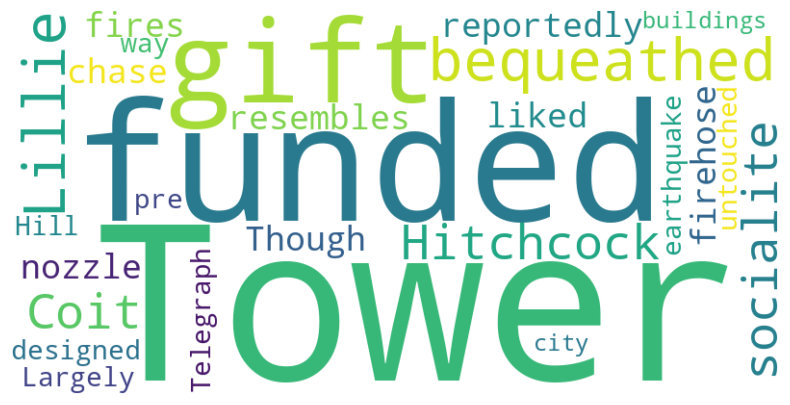

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(ffacts)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### DB SQL Engines

**Sistemas / motores SQL (engine) para Big Data** (focados naqueles que suportam SQL ou linguagens semelhantes a SQL para cargas analíticos em larga escala). São principalmente data warehouses, motores SQL-on-Hadoop/lakehouse ou serviços de consulta serverless, e não bancos de dados OLTP tradicionais.

| Sistema / Produto             | Tipo / Descrição                              | Motor / Runtime Principal por Trás dos Panos                  | Observações / Armazenamento Típico                  |
|-------------------------------|-----------------------------------------------|---------------------------------------------------------------|-----------------------------------------------------|
| **Google BigQuery**           | Data warehouse serverless na nuvem            | **Dremel** (com Borg para gerenciamento de recursos, armazenamento Colossus, rede Jupiter) | Formato colunar Capacitor; também suporta Iceberg via BigLake |
| **Apache Hive**               | Data warehouse SQL no Hadoop                  | **Tez** (padrão/moderno), MapReduce (legado) ou Spark        | HDFS / object storage (Parquet, ORC, etc.); Hive Metastore |
| **Apache Spark SQL**          | Módulo SQL do Apache Spark                    | **Spark** (otimizador Catalyst + execução Tungsten)          | HDFS, S3, Delta Lake, Iceberg, etc.                |
| **Trino** (antigo PrestoSQL)  | Motor de consulta SQL interativo distribuído  | Motor MPP próprio do Trino                                   | Federado (Hive, Iceberg, S3, RDBMS, etc.)          |
| **Presto** (PrestoDB)         | Motor de consulta SQL interativo distribuído  | Motor próprio do Presto (aceleração Velox em andamento)      | Similar ao Trino; fontes federadas                 |
| **Apache Impala**             | SQL MPP de baixa latência no Hadoop           | Motor MPP nativo do Impala (daemons nos DataNodes)           | HDFS, Parquet/ORC, Kudu                            |
| **Amazon Athena**             | SQL interativo serverless no S3               | Baseado em **Presto / Trino**                                | Amazon S3 (Parquet, ORC, Iceberg, etc.)            |
| **Amazon Redshift**           | Data warehouse na nuvem                       | Motor MPP proprietário (baseado em linhagem PostgreSQL)      | Armazenamento gerenciado Redshift ou Spectrum no S3 |
| **Snowflake**                 | Data warehouse na nuvem                       | Motor proprietário (virtual warehouses)                      | Armazenamento em nuvem Snowflake (multi-cloud)     |
| **Databricks SQL**            | Análise SQL no Databricks Lakehouse           | Motor Photon (vetorizado) + Apache Spark                     | Delta Lake / Unity Catalog                         |
| **Apache Drill**              | SQL sem esquema em dados diversos             | Motor distribuído próprio do Drill                           | HDFS, NoSQL, arquivos, etc.                        |
| **Apache Phoenix**            | Camada SQL sobre HBase                        | Phoenix (compila para HBase + coprocessors)                  | HBase                                              |
| **ClickHouse**                | Banco de dados OLAP colunar                   | Motor de alto desempenho próprio do ClickHouse               | Armazenamento MergeTree local ou distribuído       |
| **Apache Flink SQL**          | SQL de streaming + batch                      | Runtime do Apache Flink                                      | Diversos (Kafka, Iceberg, etc.)                    |
| **Dremio**                    | Lakehouse / análise self-service              | Motor baseado em Apache Arrow do Dremio                      | Data lake (Parquet, Iceberg, etc.)                 |

### Notas rápidas sobre os exemplos mencionados
- **BigQuery**: Totalmente gerenciado/serverless. As consultas são executadas pelo motor **Dremel** da Google (execução massivamente paralela baseada em árvore). O armazenamento é separado (Colossus).
- **Hive**: Traduz HiveQL em jobs que rodam em **Tez** (preferido por desempenho via execução em DAG), MapReduce ou Spark. Depende do Hive Metastore para o esquema.

Esses sistemas se destacam em cargas analíticos (OLAP) em dados na escala de petabytes. Muitas configurações modernas usam formatos de tabela abertos (Iceberg, Delta Lake, Hudi) para que vários motores possam consultar os mesmos dados. A escolha depende das necessidades de latência (interativo vs. batch), preferência de nuvem e ecossistema existente (Hadoop, nuvem pura, lakehouse).

**Vamos aprender mais sobre SQL no contexto de Big Data nas próximas aulas...**

## LAB: DOJO

- Alunos voluntariamente compartilham sua tela, piloto
- Os demais ajudam, copiloto
- Encontrar uma base interessante no BigQuery
- Estabelecer questões interessantes sobre os dados disponíveis
- Realizar consultas SQL com base nas perguntas

> Alunos podem compartilharem experiências em projetos com SQL

## Referências

- https://books.goalkicker.com/SQLBook/
- https://www.w3schools.com/sql/
- https://seaborn.pydata.org/
- https://db-engines.com/en/ranking

## Infográficos

Dicas de SQL e BD:

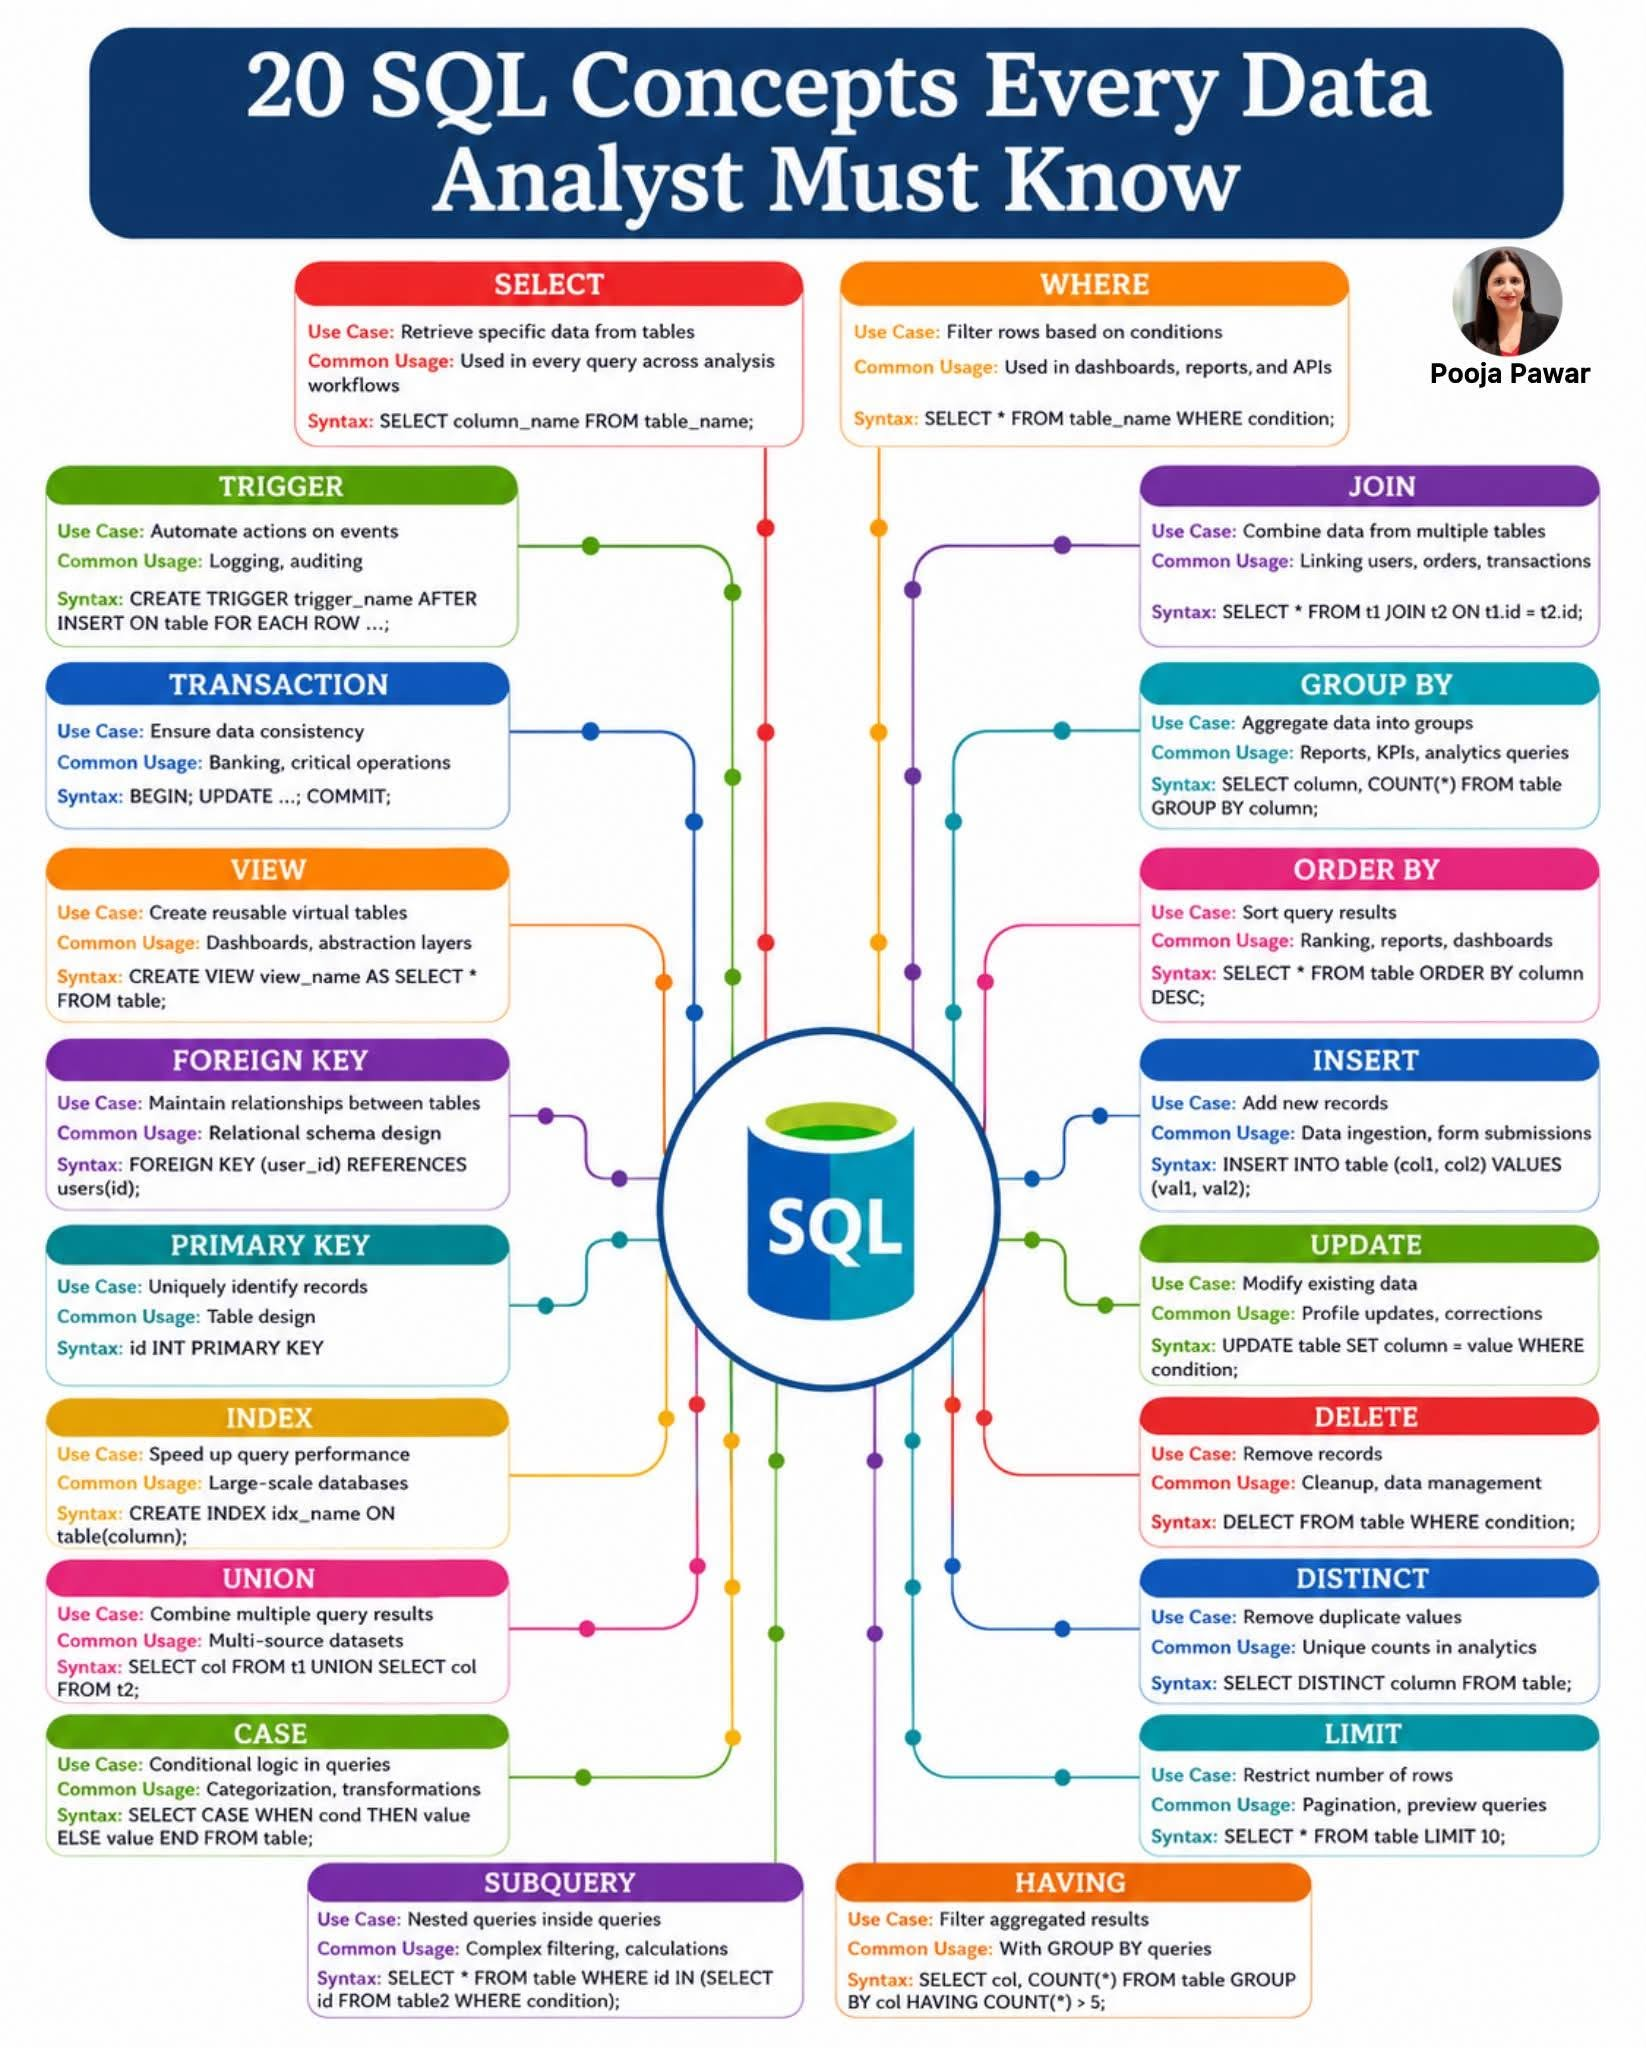

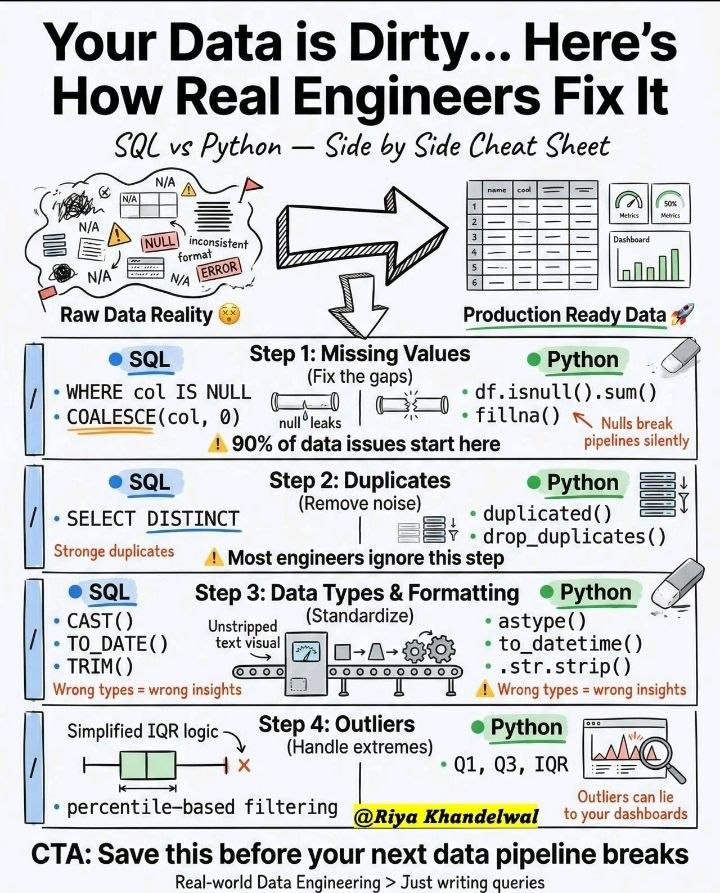